# Paper annual cycle plots

With physics + Arctic snow code modifications v1 (subli correct v2)

In [2]:
# Env: sc2_v0
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy import stats
import xesmf as xe # For regridding (https://xesmf.readthedocs.io/en/latest/)
import calendar
import os

In [3]:
# https://www.w3schools.com/python/python_classes.asp

class Site:
  def __init__(self, name, long_name, location, lat, lon, elevation, period, start, stop, period_used, run):
    self.name = name
    self.long_name = long_name
    self.location = location
    self.lat = lat
    self.lon = lon
    self.elevation = elevation
    self.period = period
    self.start = start
    self.stop = stop
    self.period_used = period_used
    self.run = run

exps = [
    'DEF',
    # 'BUG_CORRECT',
    # 'BUG_CORRECT_TSNBT_OP1',
    'BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'PHYS_ALL_SUBLI_CORRECT',
    'PHYS_ALL_SUBLI_v2',
    # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
    'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne', # best with TVC

]

# SnowMIP
cdp = Site('cdp', 'Col de Porte, France', '45.30°N, 5.77°E', 45.30, 5.77, '1325 m', 
           '1 October 1994 to 30 September 2014', '1994-10-01', '2014-09-30', slice('1994-10-01', '2014-09-30'), exps)

rme = Site('rme', 'Reynolds Mountain East, Idaho, USA', '43.19°N, 116.78°W', 43.19, -116.78, '2060 m', 
           '1 October 1988 to 30 September 2008', '1988-10-01', '2008-09-30', slice('1988-10-01', '2008-09-30'), exps)

snb = Site('snb', 'Senator Beck, Colorado, US', '37.91°N, 107.73°W', 37.91, -107.73, '3714 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

swa = Site('swa', 'Swamp Angel, Colorado, USA', '37.91°N, 107.71°W', 37.91, -107.71, '3371 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sap = Site('sap', 'Sapporo, Japan', '43.08°N, 141.34°E', 43.08, 141.34, '15 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sod = Site('sod', 'Sodankylä, Finland', '67.37°N, 26.63°E', 67.37, 26.63, '179 m', 
           '1 October 2007 to 30 September 2014', '2007-10-01', '2014-09-30', slice('2007-10-01', '2014-09-30'), exps)

wfj = Site('wfj', 'Weissfluhjoch, Switzerland', '46.83°N, 9.81°E', 46.83, 9.81, '2540 m', 
           '1 September 1996 to 31 August 2016', '1996-10-01', '2016-08-31', slice('1996-10-01', '2016-08-31'), exps)

# Arctic 
byl = Site('byl', 'Bylot Island, Canadian high Arctic', '73.15°N, 80.00°W', 73.15, -80.00, '25 m', 
           '11 July 2013 to 25 June 2019', '2013-07-11', '2019-06-25', slice('2014-07-11', '2019-06-25'), 
           [
               'peat_DEF',
               # 'peat_BUG_CORRECT',
               # 'peat_BUG_CORRECT_TSNBT_OP1',
               'peat_BUG_CORRECT_TSNBT_OP1_EZERO',
               # 'peat_PHYS_ALL_SUBLI_CORRECT',
               'peat_PHYS_ALL_SUBLI_v2',
               # 'peat_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne',
           ])

umt = Site('umt', 'Umiujaq TUNDRA, northeastern Canada', '56.55877°N, 76.48234°W', 56.55877, -76.48234, '132 m', 
           '28 Sept 2012 to 15 October 2021', '2012-09-28', '2021-10-15', slice('2016-09-01', '2021-08-31'), 
           [
               'DEF_correct_SH',
               # 'BUG_CORRECT',
               # 'BUG_CORRECT_TSNBT_OP1',
               'BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT',
               'PHYS_ALL_SUBLI_v2_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])


tvc = Site('tvc', 'Trail Valley Creak, northwestern Canada', '68.74617°N, 133.50171°W', 68.74617, -133.50171, '85 m', 
           '01 Oct 2017 to 30 Sept 2019', '2017-10-01', '2019-09-30', slice('2017-10-01', '2019-09-30'), 
           [
               '1peat_2xSnowf_DEF_correct_SH',
               # '1peat_2xSnowfBUG_CORRECT',
               # '1peat_2xSnowfBUG_CORRECT_TSNBT_OP1',
               '1peat_2xSnowf_BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])

# umf = Site('umf', 'Umiujaq FOREST, northeastern Canada', '56.55308°N, 76.47258°W', 56.55308, -76.47258, '82 m', 
#            '26 Nov 2015 to 19 October 2021', '2015-11-26', '2021-10-19', slice('2018-09-01', '2021-08-31'), 
#            ['Ref', 'EZERO'])


In [4]:
SnowMIP_sites = [cdp, rme, snb, swa, sap, sod, wfj]
# SnowMIP_sites = [cdp, rme, snb, sap, sod, wfj]
SnowArctic_sites = [byl, umt, tvc]

path_SnowMIP = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowMIP/'
path_SnowArctic = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'
path_Paul = '/home/mickael-lalande/Dropbox/data/SnowMIP/Paul/CLASS_Results'

ds_d_SnowMIP_list = []
for i, exp in enumerate(exps):
    paths_SnowMIP = [path_SnowMIP+site.name+'/'+'run_'+exp for site in SnowMIP_sites]
    # Change the syntax as the ref run is not necessarily having the same name for all sites
    paths_SnowArctic = [path_SnowArctic+site.name+'/'+'run_'+site.run[i] for site in SnowArctic_sites]
    paths = paths_SnowMIP + paths_SnowArctic
    ds_d_SnowMIP_list.append([xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths])


# ds_d_Paul_list = []
# for site in SnowMIP_sites:
#     df_Paul = pd.read_csv(path_Paul+'/CLASS_sv_REF_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.txt', delim_whitespace=True)
#     df_Paul.index = pd.to_datetime(df_Paul[['year', 'month', 'day', 'hour']]).values
#     df_Paul= df_Paul.drop(columns=['year', 'month', 'day', 'hour'])
#     df_Paul.albsn = df_Paul.albsn.replace({0 : np.nan})
#     df_Paul.albs = df_Paul.albs.replace({0 : np.nan})
#     df_Paul.tsn = df_Paul.tsn.replace({-999 : np.nan})
#     df_Paul.tsns = df_Paul.tsns.replace({-999 : np.nan})
#     ds_Paul_h = df_Paul.to_xarray()
#     ds_Paul_h = ds_Paul_h.rename({'index': 'time'})
#     ds_Paul_d = ds_Paul_h.resample(time='D').mean().load()
#     ds_Paul_d = ds_Paul_d.assign_coords(layer=[0.05 , 0.225, 2.225]) # center of Paul's soil layers (DELZ = [0.1, 0.25, 3.75])
    

#     # Combine the Soil temperature in one variable
#     ds_Paul_d = ds_Paul_d.assign(
#         tsl=(('layer', 'time'), [
#             list(ds_Paul_d['tsl:1'].values),
#             list(ds_Paul_d['tsl:2'].values),
#             list(ds_Paul_d['tsl:3'].values),
#         ])
#     )
        
#     ds_d_Paul_list.append(ds_Paul_d)

## Set soil levels

In [5]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowMIP/cdp"
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref.nc')

In [6]:
def assign_center_depth(ds, rsfile):
    layer_c = []
    for i in range(len(rsfile.DELZ)):
        if i == 0:
            layer_c.append(rsfile.DELZ.cumsum().values[i]/2)
        else:
            layer_c.append(rsfile.DELZ.cumsum().values[i-1] + rsfile.DELZ.values[i]/2)
    with xr.set_options(keep_attrs=True):
        ds = ds.assign_coords(layer=ds.layer*0+layer_c)
    return ds

In [7]:
for i, exp in enumerate(exps):
    for j in range(len(SnowMIP_sites+SnowArctic_sites)):
        ds_d_SnowMIP_list[i][j] = assign_center_depth(ds_d_SnowMIP_list[i][j], rsfile)

## Convert noleap year cftime to datetime

In [8]:
for i in range(len(tvc.run)):
    ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
    ds_d_SnowMIP_list[i][-1] = ds_d_SnowMIP_list[i][-1].reindex(
        time=pd.date_range(
            ds_d_SnowMIP_list[i][-1]['time'][0].values, 
            ds_d_SnowMIP_list[i][-1]['time'][-1].values
        )
    )

/tmp/ipykernel_119159/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
/tmp/ipykernel_119159/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
/tmp/ipykernel_119159/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates fro

## Compare with obs

In [9]:
path_menard2019 = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all'

ds_d_Obs_list = []
for site in SnowMIP_sites:
    ds_h_eval_menard2019 = xr.open_dataset(path_menard2019+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc')
    ds_d_eval_menard2019 = ds_h_eval_menard2019.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_eval_menard2019)

In [10]:
path_obs_byl = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Bylot'
path_obs_umt = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
# path_obs_umf = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
path_obs_tvc = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/TVC/TVCSnowCLM/TVCMetData'

# path_obs_list = [path_obs_byl, path_obs_umt, path_obs_umf]
path_obs_list = [path_obs_byl, path_obs_umt, path_obs_tvc]
for site, path in zip(SnowArctic_sites, path_obs_list):
    ds_h_obs = xr.open_dataset(path+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc').load()
    if site.name == 'byl':
        ds_h_obs['albs'] = ds_h_obs.albs.where(ds_h_obs.flag_albs_ERA5 == 0).where(ds_h_obs.albs < 1) # to avoid > 1 albedo values
    if site.name == 'umt':
        ds_h_obs = ds_h_obs.mean(dim='veg') # average over lichen and lowshrub area (tsl)
    if site.name in ['tvc']:
        ds_h_obs['snd_auto'] = ds_h_obs.snd_auto/100
        ds_h_obs = ds_h_obs.rename({'albedo': 'albs', 'swc': 'mrsll'})
    # Remove albs for Arctic sites (wrong values)
    if site.name in ['byl', 'umt', 'tvc']:
        ds_h_obs = ds_h_obs.drop_vars('albs')
        
    ds_d_obs = ds_h_obs.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_obs)

## Merge Arctic and SnowMIP

In [11]:
# ds_d_Obs_list = ds_d_Obs_list + ds_d_Obs_Arctic_list
# ds_d_SnowMIP_list = ds_d_SnowMIP_list + ds_d_SnowArctic_list

### SD

In [12]:
exps

['DEF',
 'BUG_CORRECT_TSNBT_OP1_EZERO',
 'PHYS_ALL_SUBLI_v2',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
 'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne']

In [13]:
label_exps = ['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']

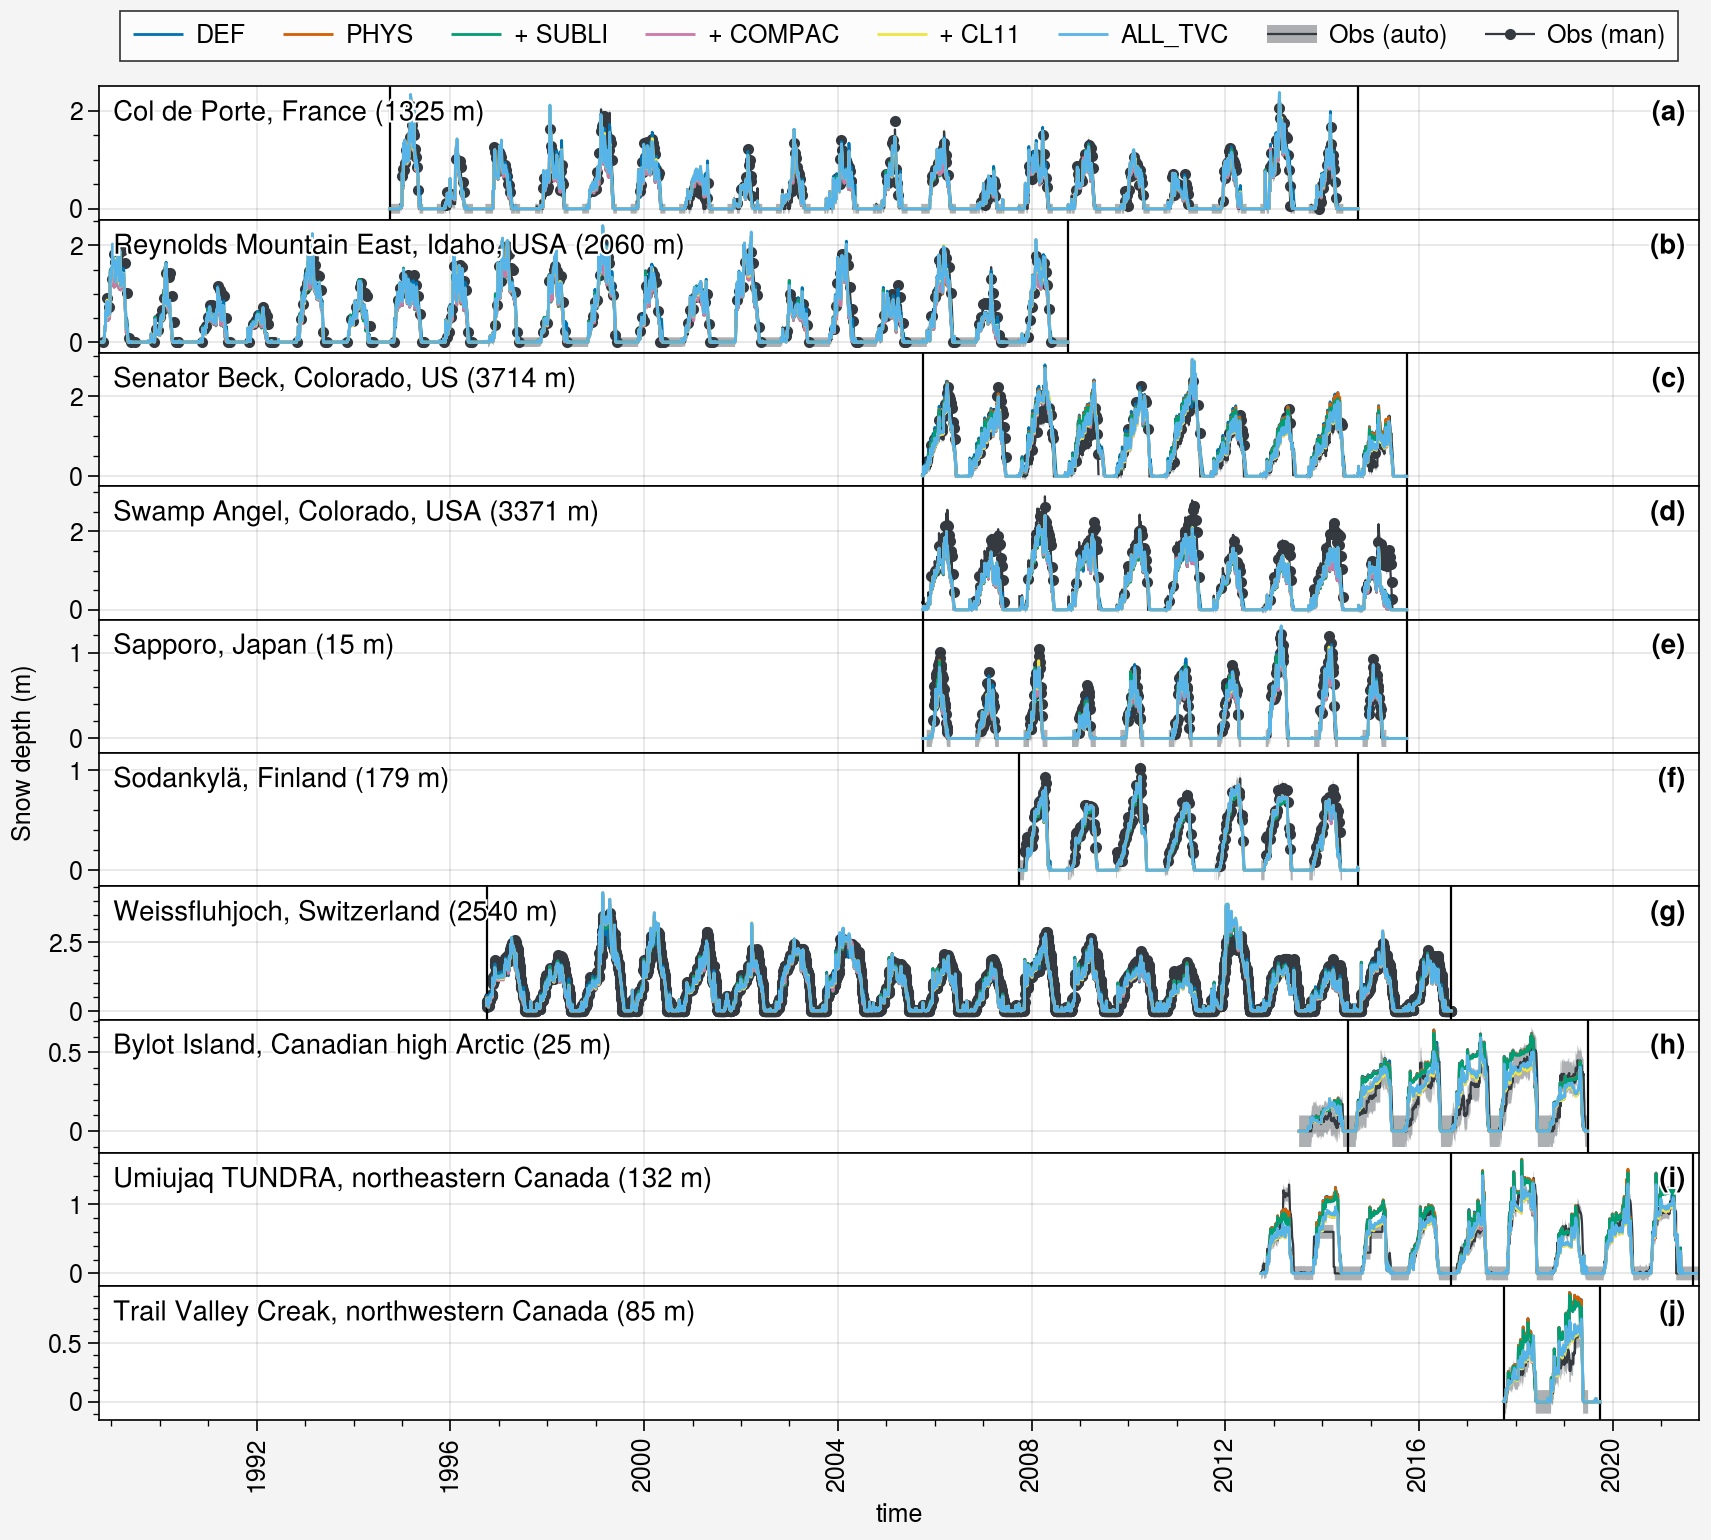

In [14]:
fig, axs = pplt.subplots(nrows=len(SnowMIP_sites+SnowArctic_sites), refaspect=12, refwidth=8, space=0)

color_obs = 'gray8'

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    # Model 
    h_exps = []
    # for j, exp in enumerate(exps): 
    for j, exp in enumerate(label_exps): 
        h = axs[i].plot(ds_d_SnowMIP_list[j][i].snd.sel(time=slice(site.start, site.stop)), label=exp, lw=1)
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = axs[i].plot(ds_d_Paul_list[i].snd.sel(time=slice(site.start, site.stop)), label='CLASS', color='red9', lw=1)
    
    # Obs
    shadedata = np.concatenate((
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values+0.1, axis=0),
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values-0.1, axis=0),), axis=0)
    h_obs_auto = axs[i].plot(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)), shadedata=shadedata, color=color_obs, 
                zorder=0, lw=0.8, label='Obs (auto)')
    
    if 'snd_man' in list(ds_d_Obs_list[i].keys()):
        h_obs_man = axs[i].plot(ds_d_Obs_list[i].snd_man.sel(time=slice(site.start, site.stop)), marker='.', color=color_obs, 
                    zorder=0, lw=0.8, label='Obs (man)')
    
    axs[i].format(ylabel='Snow depth (m)', ultitle=site.long_name+' ('+site.elevation+')')
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[0], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[-1], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    


# axs[4].legend(ncols=5, loc='ll')
# fig.legend(h_exps+h_paul+h_obs_auto+h_obs_man, ncols=2, loc='t')
fig.legend(h_exps+h_obs_auto+h_obs_man, ncols=8, loc='t')

fig.format(abc='(a)', abcloc='ur')

# fig.suptitle('Col de Porte, France, 1325 m')
# fig.save('img/tn1_sd_correct_SH.jpg')

### Annual cycles

In [15]:
[site.name for site in SnowMIP_sites+SnowArctic_sites]

['cdp', 'rme', 'snb', 'swa', 'sap', 'sod', 'wfj', 'byl', 'umt', 'tvc']

In [16]:
label_exps[:]

['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']

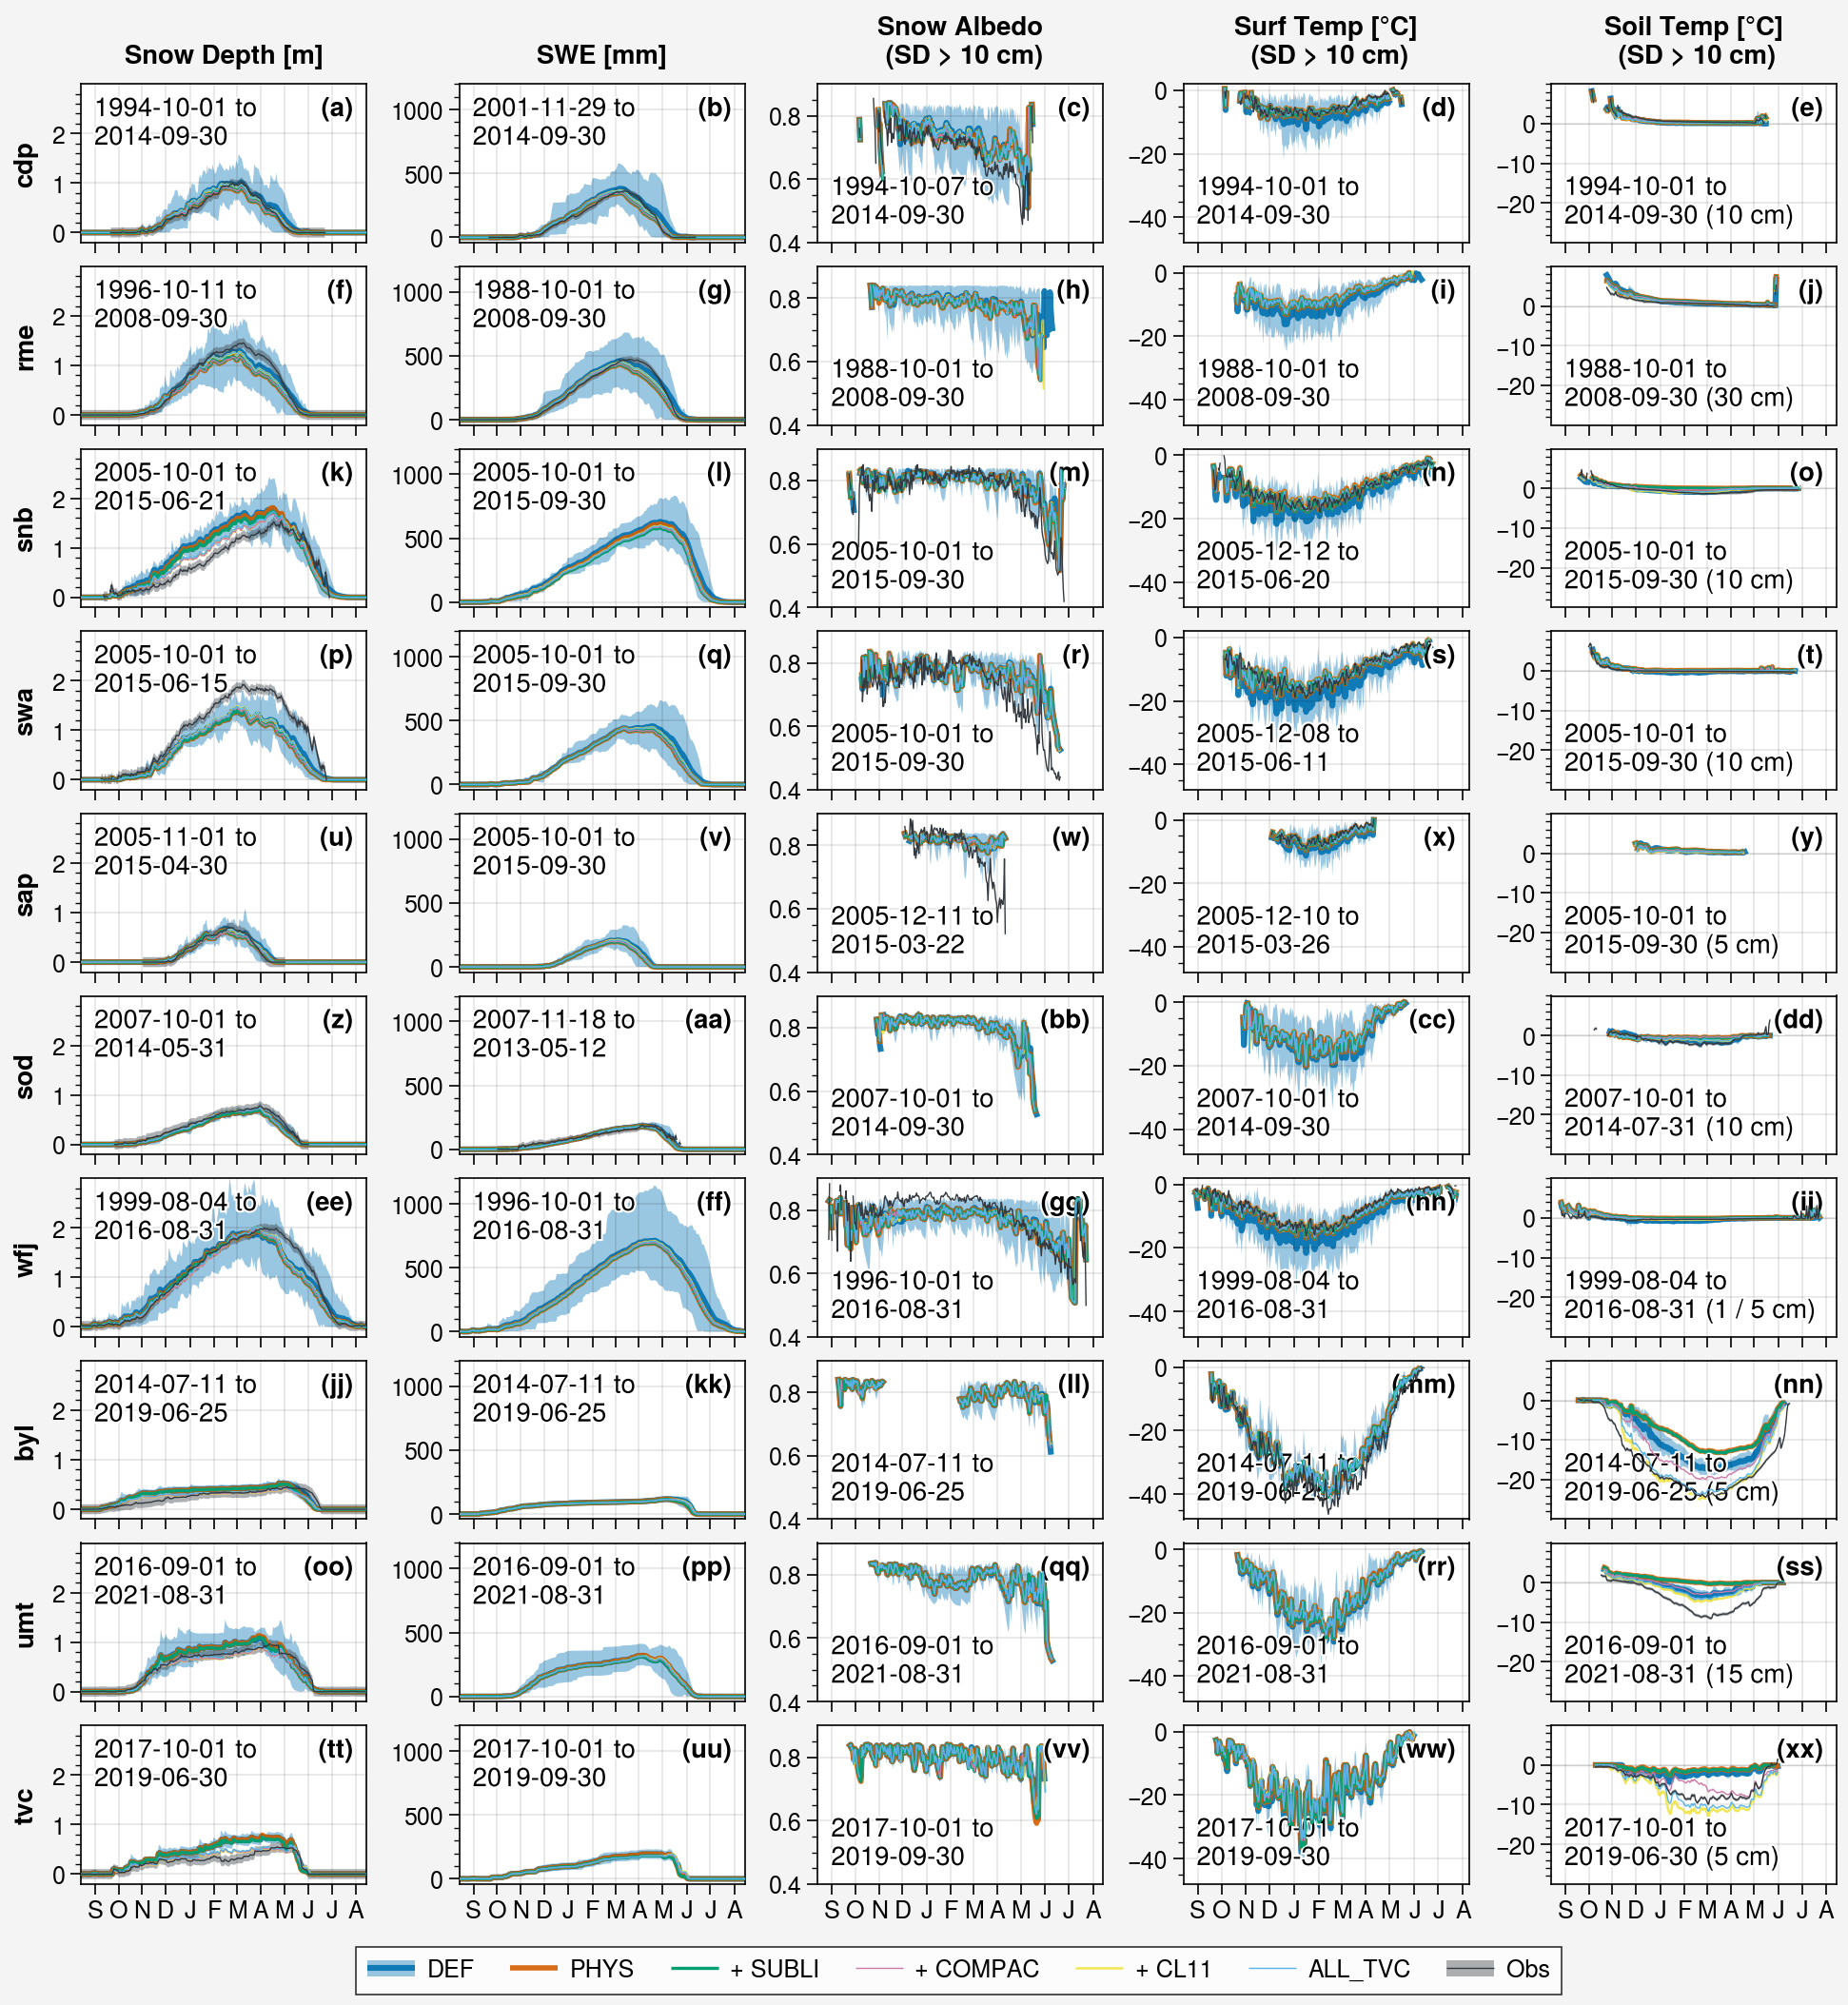

In [17]:
import warnings
warnings.filterwarnings("ignore")

color_obs = 'gray8'

# Shifted DOY tick positions (non-leap year, shift = -140)
# These are the first DOY of each corresponding month in the shifted calendar
xticks = [
    19,   # Sep
    49,   # Oct
    79,   # Nov
    109,  # Dec
    140,  # Jan
    171,  # Feb
    200,  # Mar
    230,  # Apr
    260,  # May
    291,  # Jun
    321,  # Jul
    352   # Aug (closing)
]

# Corresponding month initials
xlabels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']


# -------------------------------------------------------------------
# Styles (ONLY addition)
# -------------------------------------------------------------------
lw_def,    zorder_def,    alpha_def    = 2.2,  1,  0.9   # blue
lw_phys,   zorder_phys,   alpha_phys   = 2.0,  2,  0.9   # orange
lw_subli,  zorder_subli,  alpha_subli  = 1.2,  8,  1.0   # green
lw_compac, zorder_compac, alpha_compac = 0.5,  9,  1.0   # pink
lw_cl11,   zorder_cl11,   alpha_cl11   = 0.9,  2,  0.9   # yellow
lw_tvc,    zorder_tvc,    alpha_tvc    = 0.5, 10,  1.0   # light blue

def style(exp):
    if exp == 'PHYS':
        return dict(lw=lw_phys,   zorder=zorder_phys,   alpha=alpha_phys)
    elif exp == '+ SUBLI':
        return dict(lw=lw_subli,  zorder=zorder_subli,  alpha=alpha_subli)
    elif exp == '+ COMPAC':
        return dict(lw=lw_compac, zorder=zorder_compac, alpha=alpha_compac)
    elif exp == '+ CL11':
        return dict(lw=lw_cl11,   zorder=zorder_cl11,   alpha=alpha_cl11)
    elif exp == 'ALL_TVC':
        return dict(lw=lw_tvc,    zorder=zorder_tvc,    alpha=alpha_tvc)
    else:
        return dict(lw=0.5, zorder=5, alpha=1.0)


# fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0)
fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0, hspace=1, refaspect=1.8)

# for i, site in enumerate([cdp]):
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):

    doy = 140
    period = site.period_used

    # Snow depth
    ax = axs[i*5+0]
    mask_obs = ~ds_d_Obs_list[i].snd_auto.sel(time=period).isnull()

    shadedata = ds_d_SnowMIP_list[0][i].snd.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
    h1 = ax.plot(ds_d_SnowMIP_list[0][i].snd.sel(time=period).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 shadedata=shadedata, label=label_exps[0],
                 zorder=zorder_def, lw=lw_def, alpha=alpha_def)

    h_exps = []
    for j, exp in enumerate(label_exps[1:]):
        st = style(exp)
        h = ax.plot(ds_d_SnowMIP_list[j+1][i].snd.sel(time=period).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = ax.plot(ds_d_Paul_list[i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
    #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

    obs = ds_d_Obs_list[i].snd_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
    shadedata = np.concatenate((np.expand_dims(obs.values+0.1, axis=0), np.expand_dims(obs.values-0.1, axis=0),), axis=0)
    h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
    ax.format(ylabel='', xlabel='', ylim=(-0.2,3), yticks=[0, 1, 2],
              ultitle=str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
              str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[-1].values)[:10],
              xticks=xticks, xticklabels=xlabels, xtickminor=False)
    # ax.legend(h1+h_exps+h_paul+h_obs, loc='ul', ncols=1)

    # Snow Water Equivalent
    ax = axs[i*5+1]

    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].snw_auto.sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+25, axis=0), np.expand_dims(obs.values-25, axis=0),), axis=0)
        h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-40,1200),
                  ultitle=str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-40,1200), ultitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Albedo (need to add a condition albsn > 0.4 because a few values are 0 in the model -> bug? (e.g., at Saporo)
    # + low values are observed in the begining of the season (probably due to not full SCF coveraged)
    ax = axs[i*5+2]
    lim_alb = 0.4
    lim_alb_sup = 0.9

    if 'albs' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > lim_alb).where(ds_d_Obs_list[i].albs < lim_alb_sup)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                     .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                     .where(ds_d_Paul_list[i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)
        if site not in ['umt', 'byl']:
            obs = ds_d_Obs_list[i].albs.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
            h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
            ax.format(ylabel='', ylim=(0.4,0.9),
                      lltitle=str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                      .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(0.4,0.9), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Surface temperature
    # Add condition on ts <= 0 on obs to avoid melting pachy areas to be counted
    ax = axs[i*5+3]

    if 'ts' in list(ds_d_Obs_list[i].keys()) and ds_d_Obs_list[i].ts.notnull().sum() != 0:
        mask_obs = ~ds_d_Obs_list[i].ts.sel(time=period).where(ds_d_Obs_list[i].ts <= 0)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].ts.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-48,2),
                  lltitle=str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-48,2), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Soil temperature
    ax = axs[i*5+4]

    if 'tsl' in list(ds_d_Obs_list[i].keys()):

        # Get the first soil layer from obs (except for byl)
        if site.name in ['byl', 'tvc']:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0) # 0.05 instead of 0.02
        else:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0)

        # For wfj (otherwise NaN so take the first model level)
        if obs_sdepth < 0.01:
            model_sdepth = 0.05
        else:
            model_sdepth = obs_sdepth
        mask_obs = ~ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        # Interp model on the first soil layer obs
        if obs_sdepth < 0.01:
            ds_d_interp = ds_d_SnowMIP_list[0][i]
        else:
            ds_d_interp = ds_d_SnowMIP_list[0][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

        shadedata = ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            if obs_sdepth < 0.01:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i]
            else:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

            st = style(exp)
            h = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     if obs_sdepth < 0.01:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     else:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+0.4, axis=0), np.expand_dims(obs.values-0.4, axis=0),), axis=0)
        h_obs = ax.plot(obs, label='Obs', shadedata=shadedata, color=color_obs, lw=0.5, zorder=10)
        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        if site.name == 'byl':
            ylim=(-30, 10)
        else:
            ylim=(-30, 10)
            # ylim=(-5, 10)
        if obs_sdepth != model_sdepth:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' / '+str(round(model_sdepth*100))+' cm)')
        else:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' cm)')

    else:
        model_sdepth = 0.05 # first level

        shadedata = ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        ax.format(ylabel='', xlabel='', ylim=ylim, yticks=[0, -10, -20], lltitle=period.start+' to\n'+ period.stop+' ('+\
                     str(round(model_sdepth*100))+' cm)', xticks=xticks, xticklabels=xlabels, xtickminor=False)


for ax in axs:
    ax.format(xlabel='')

fig.format(abc='(a)', abcloc='ur',
           collabels=['Snow Depth [m]', 'SWE [mm]', 'Snow Albedo\n (SD > 10 cm)', 'Surf Temp [°C]\n (SD > 10 cm)',
                      'Soil Temp [°C]\n (SD > 10 cm)'],
           rowlabels=[site.name for site in SnowMIP_sites+SnowArctic_sites])
# fig.legend(h1+h_exps+h_paul+h_obs, loc='b', ncols=2)
fig.legend(h1+h_exps+h_obs, loc='b', ncols=8)

# fig.save('img/paper_ac_all_v3_correct_SH.jpg')
# fig.save('img/paper_ac_all_v3_correct_SH.png')
# fig.save('img/paper_ac_all_v3_correct_SH.pdf')


In [18]:
def fill_snowdepth_gaps(da, long_gap_days=50):
    """
    Fill snow-depth time series:
    - NaN gaps <= long_gap_days: linear interpolation
    - NaN gaps > long_gap_days: set to 0
    
    Intended for plotting seasonal cycles, not necessarily for metrics.
    """
    s = da.to_series().copy()
    is_nan = s.isna()

    # Identify consecutive NaN / non-NaN runs
    run_id = (is_nan != is_nan.shift(fill_value=False)).cumsum()

    s_filled = s.copy()

    for _, idx in s[is_nan].groupby(run_id[is_nan]).groups.items():
        gap_len = len(idx)

        if gap_len > long_gap_days:
            # Long summer-like missing period -> assume snow-free
            s_filled.loc[idx] = 0.0

    # Remaining shorter NaN gaps -> linear interpolation
    s_filled = s_filled.interpolate(method="time", limit_area="inside")

    return xr.DataArray(
        s_filled,
        dims=da.dims,
        coords=da.coords,
        attrs=da.attrs,
        name=da.name
    )

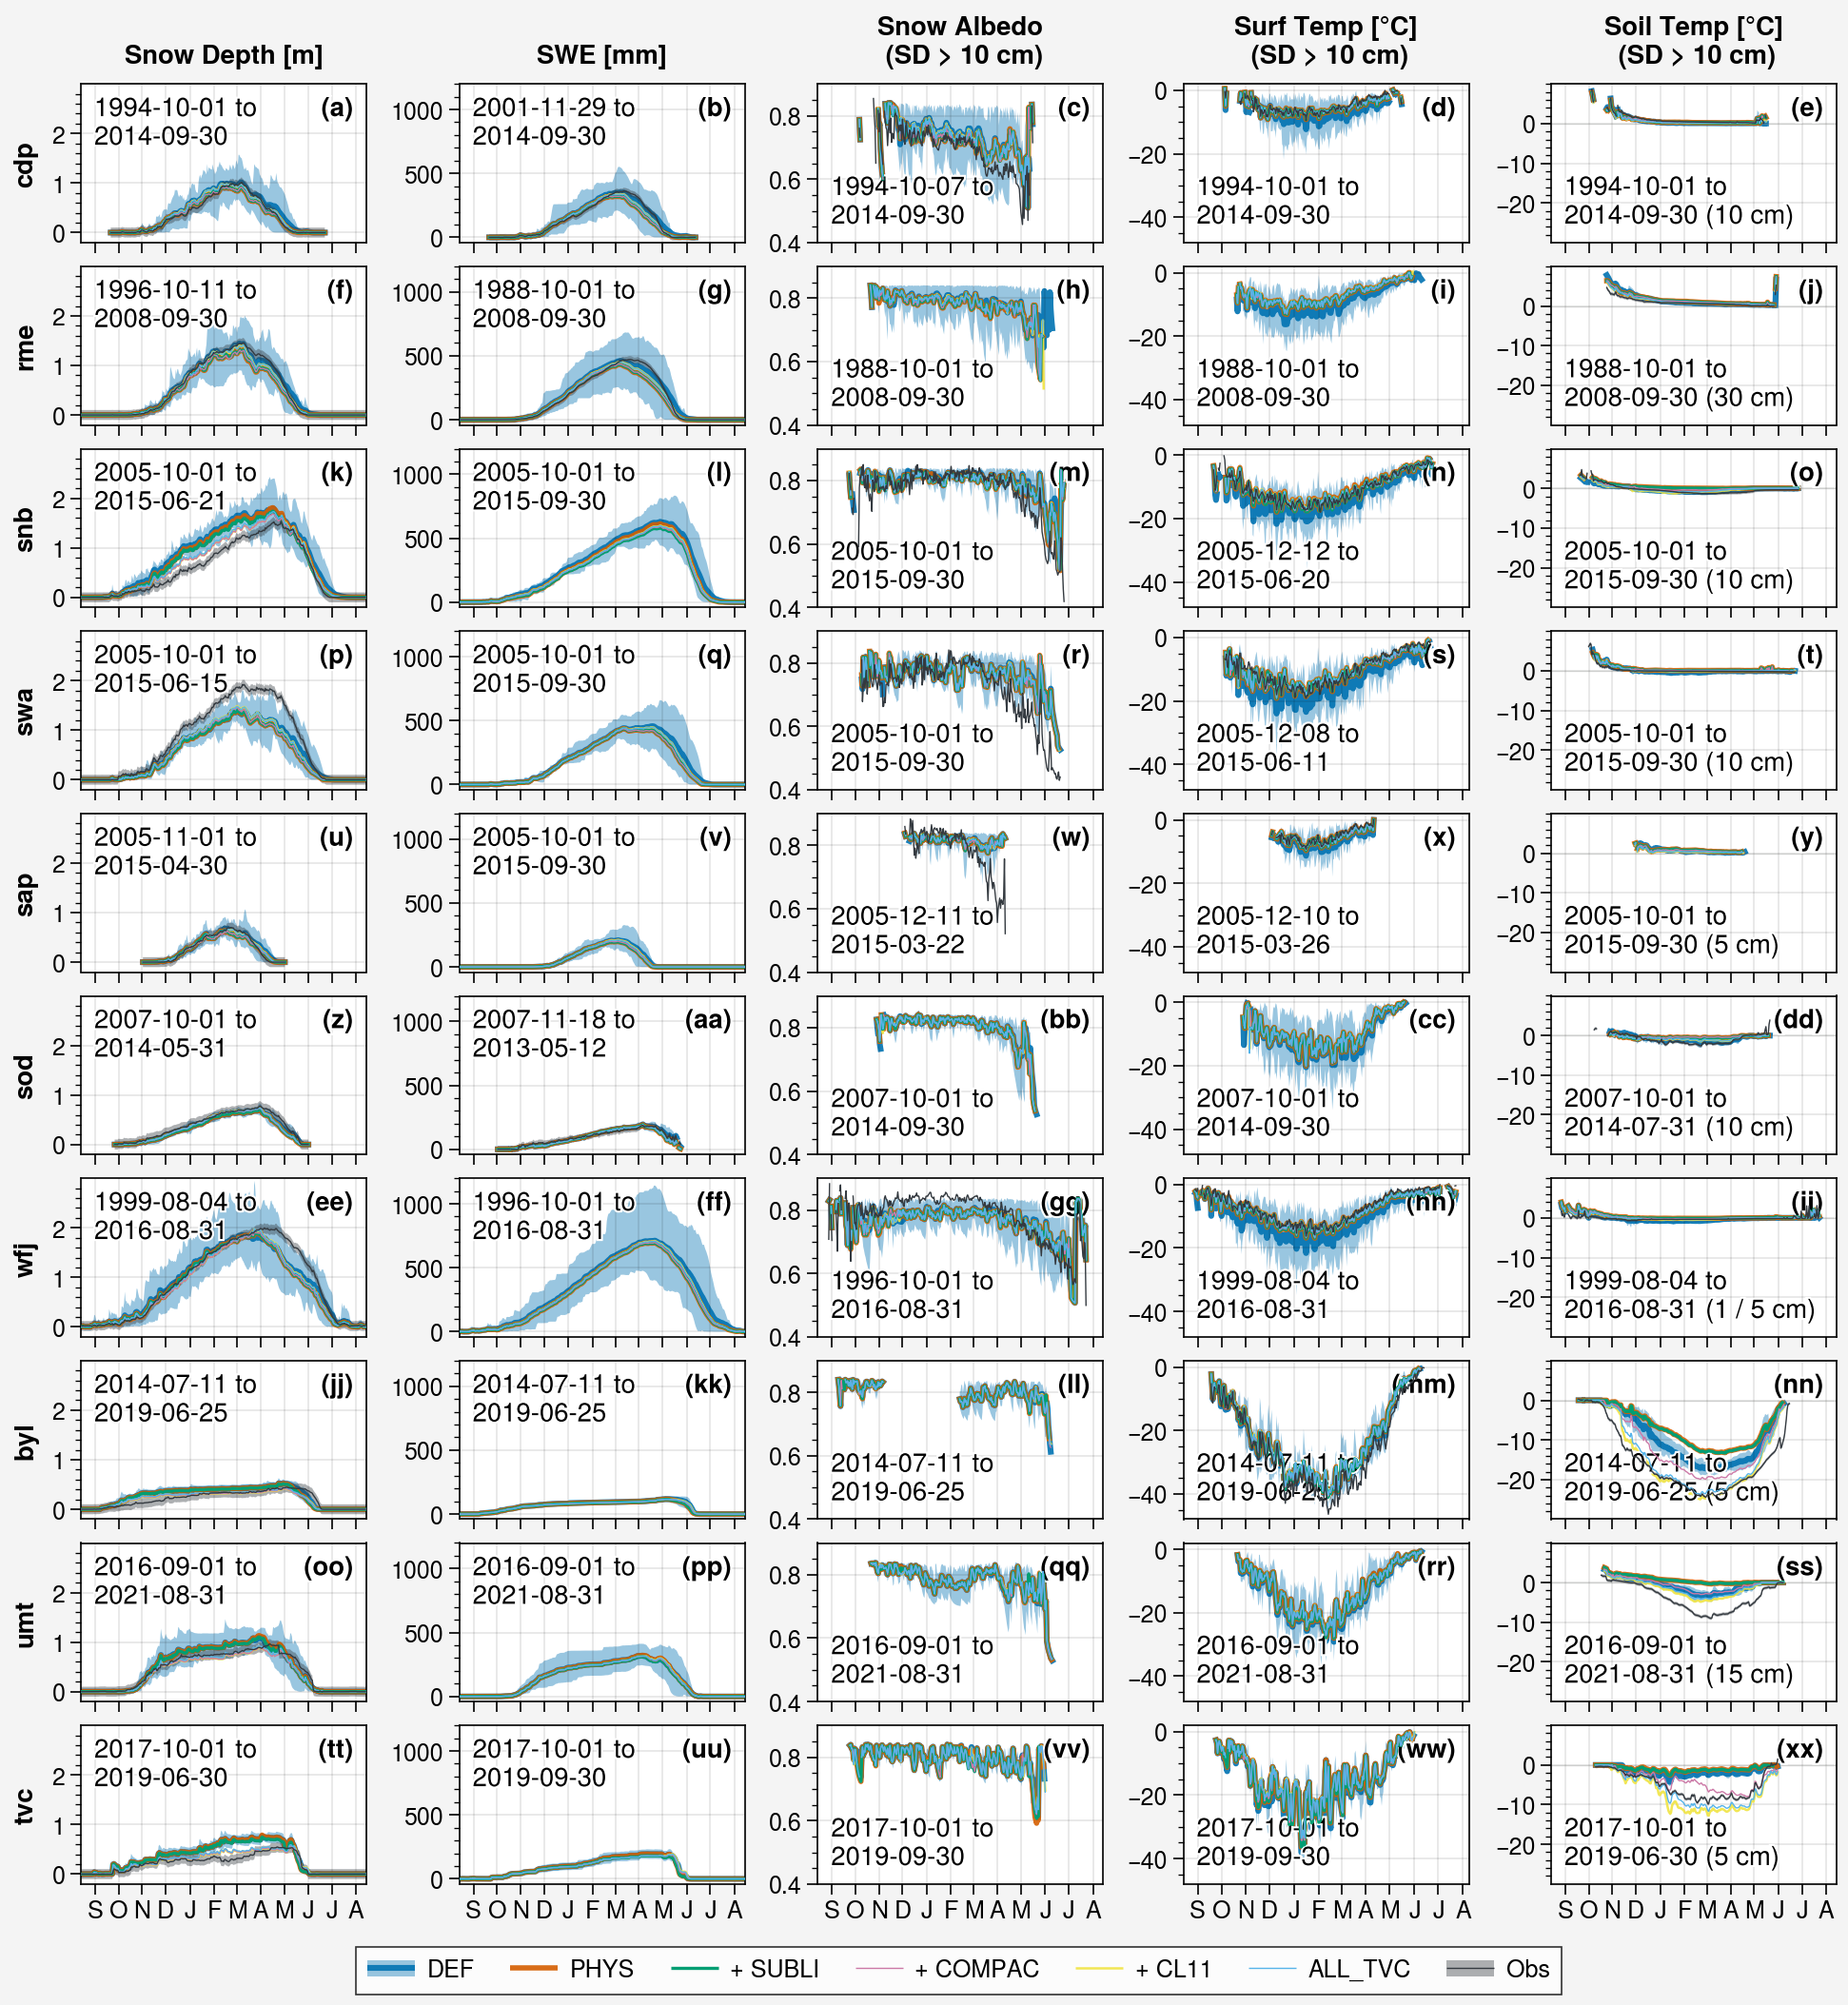

In [35]:
import warnings
warnings.filterwarnings("ignore")

color_obs = 'gray8'

# Shifted DOY tick positions (non-leap year, shift = -140)
# These are the first DOY of each corresponding month in the shifted calendar
xticks = [
    19,   # Sep
    49,   # Oct
    79,   # Nov
    109,  # Dec
    140,  # Jan
    171,  # Feb
    200,  # Mar
    230,  # Apr
    260,  # May
    291,  # Jun
    321,  # Jul
    352   # Aug (closing)
]

# Corresponding month initials
xlabels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']


# -------------------------------------------------------------------
# Styles (ONLY addition)
# -------------------------------------------------------------------
lw_def,    zorder_def,    alpha_def    = 2.2,  1,  0.9   # blue
lw_phys,   zorder_phys,   alpha_phys   = 2.0,  2,  0.9   # orange
lw_subli,  zorder_subli,  alpha_subli  = 1.2,  8,  1.0   # green
lw_compac, zorder_compac, alpha_compac = 0.5,  9,  1.0   # pink
lw_cl11,   zorder_cl11,   alpha_cl11   = 0.9,  2,  0.9   # yellow
lw_tvc,    zorder_tvc,    alpha_tvc    = 0.5, 10,  1.0   # light blue

def style(exp):
    if exp == 'PHYS':
        return dict(lw=lw_phys,   zorder=zorder_phys,   alpha=alpha_phys)
    elif exp == '+ SUBLI':
        return dict(lw=lw_subli,  zorder=zorder_subli,  alpha=alpha_subli)
    elif exp == '+ COMPAC':
        return dict(lw=lw_compac, zorder=zorder_compac, alpha=alpha_compac)
    elif exp == '+ CL11':
        return dict(lw=lw_cl11,   zorder=zorder_cl11,   alpha=alpha_cl11)
    elif exp == 'ALL_TVC':
        return dict(lw=lw_tvc,    zorder=zorder_tvc,    alpha=alpha_tvc)
    else:
        return dict(lw=0.5, zorder=5, alpha=1.0)


# fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0)
fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0, hspace=1, refaspect=1.8)

# for i, site in enumerate([cdp]):
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):

    doy = 140
    period = site.period_used

    # Snow depth
    ax = axs[i*5+0]
    if site.name in ['snb', 'swa']:
        # Fill snow depth gaps for better visualization of seasonal cycle (intended for plotting, not necessarily for metrics)
        # Works only for snd_auto covering the whole period, which is the case for these 2 sites
        snd_obs_filled = fill_snowdepth_gaps(ds_d_Obs_list[i].snd_auto, long_gap_days=50)
    else:
        snd_obs_filled = ds_d_Obs_list[i].snd_auto
    mask_obs = ~snd_obs_filled.sel(time=period).isnull()

    shadedata = ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
    h1 = ax.plot(ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 shadedata=shadedata, label=label_exps[0],
                 zorder=zorder_def, lw=lw_def, alpha=alpha_def)

    h_exps = []
    for j, exp in enumerate(label_exps[1:]):
        st = style(exp)
        h = ax.plot(ds_d_SnowMIP_list[j+1][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = ax.plot(ds_d_Paul_list[i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
    #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

    obs = snd_obs_filled.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
    shadedata = np.concatenate((np.expand_dims(obs.values+0.1, axis=0), np.expand_dims(obs.values-0.1, axis=0),), axis=0)
    h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
    ax.format(ylabel='', xlabel='', ylim=(-0.2,3), yticks=[0, 1, 2],
              ultitle=str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
              str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[-1].values)[:10],
              xticks=xticks, xticklabels=xlabels, xtickminor=False)
    # ax.legend(h1+h_exps+h_paul+h_obs, loc='ul', ncols=1)

    # Snow Water Equivalent
    ax = axs[i*5+1]

    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].snw_auto.sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+25, axis=0), np.expand_dims(obs.values-25, axis=0),), axis=0)
        h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-40,1200),
                  ultitle=str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-40,1200), ultitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Albedo (need to add a condition albsn > 0.4 because a few values are 0 in the model -> bug? (e.g., at Saporo)
    # + low values are observed in the begining of the season (probably due to not full SCF coveraged)
    ax = axs[i*5+2]
    lim_alb = 0.4
    lim_alb_sup = 0.9

    if 'albs' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > lim_alb).where(ds_d_Obs_list[i].albs < lim_alb_sup)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                     .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[j+1][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                     .where(ds_d_Paul_list[i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)
        if site not in ['umt', 'byl']:
            obs = ds_d_Obs_list[i].albs.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
            h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
            ax.format(ylabel='', ylim=(0.4,0.9),
                      lltitle=str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[j+1][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                      .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(0.4,0.9), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Surface temperature
    # Add condition on ts <= 0 on obs to avoid melting pachy areas to be counted
    ax = axs[i*5+3]

    if 'ts' in list(ds_d_Obs_list[i].keys()) and ds_d_Obs_list[i].ts.notnull().sum() != 0:
        mask_obs = ~ds_d_Obs_list[i].ts.sel(time=period).where(ds_d_Obs_list[i].ts <= 0)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].ts.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-48,2),
                  lltitle=str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-48,2), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Soil temperature
    ax = axs[i*5+4]

    if 'tsl' in list(ds_d_Obs_list[i].keys()):

        # Get the first soil layer from obs (except for byl)
        if site.name in ['byl', 'tvc']:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0) # 0.05 instead of 0.02
        else:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0)

        # For wfj (otherwise NaN so take the first model level)
        if obs_sdepth < 0.01:
            model_sdepth = 0.05
        else:
            model_sdepth = obs_sdepth
        mask_obs = ~ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        # Interp model on the first soil layer obs
        if obs_sdepth < 0.01:
            ds_d_interp = ds_d_SnowMIP_list[0][i]
        else:
            ds_d_interp = ds_d_SnowMIP_list[0][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

        shadedata = ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            if obs_sdepth < 0.01:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i]
            else:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

            st = style(exp)
            h = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     if obs_sdepth < 0.01:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     else:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+0.4, axis=0), np.expand_dims(obs.values-0.4, axis=0),), axis=0)
        h_obs = ax.plot(obs, label='Obs', shadedata=shadedata, color=color_obs, lw=0.5, zorder=10)
        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        if site.name == 'byl':
            ylim=(-30, 10)
        else:
            ylim=(-30, 10)
            # ylim=(-5, 10)
        if obs_sdepth != model_sdepth:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' / '+str(round(model_sdepth*100))+' cm)')
        else:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' cm)')

    else:
        model_sdepth = 0.05 # first level

        shadedata = ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        ax.format(ylabel='', xlabel='', ylim=ylim, yticks=[0, -10, -20], lltitle=period.start+' to\n'+ period.stop+' ('+\
                     str(round(model_sdepth*100))+' cm)', xticks=xticks, xticklabels=xlabels, xtickminor=False)


for ax in axs:
    ax.format(xlabel='')

fig.format(abc='(a)', abcloc='ur',
           collabels=['Snow Depth [m]', 'SWE [mm]', 'Snow Albedo\n (SD > 10 cm)', 'Surf Temp [°C]\n (SD > 10 cm)',
                      'Soil Temp [°C]\n (SD > 10 cm)'],
           rowlabels=[site.name for site in SnowMIP_sites+SnowArctic_sites])
# fig.legend(h1+h_exps+h_paul+h_obs, loc='b', ncols=2)
fig.legend(h1+h_exps+h_obs, loc='b', ncols=8)

# fig.save('img/paper_ac_all_v4_correct_SH.jpg')
# fig.save('img/paper_ac_all_v4_correct_SH.png')
# fig.save('img/paper_ac_all_v4_correct_SH.pdf')


In [20]:
SnowMIP_sites[2].name

'snb'

In [21]:
SnowMIP_sites[2].period_used

slice('2005-10-01', '2015-09-30', None)

In [22]:
i = 2
site = SnowMIP_sites[i]
period = site.period_used
ds_d_Obs_list[i].snd_auto.sel(time=period)

<xarray.DataArray 'snd_auto' (time: 3652)>
array([0.026, 0.061, 0.041, ...,   nan,   nan,   nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2005-10-01 2005-10-02 ... 2015-09-30
Attributes:
    long_name:  snowdepth, automatic measurement
    units:      m

In [23]:
i = 2
mask_obs = ~ds_d_Obs_list[i].snd_auto.sel(time=period).isnull()
mask_obs

<xarray.DataArray 'snd_auto' (time: 3652)>
array([ True,  True,  True, ..., False, False, False])
Coordinates:
  * time     (time) datetime64[ns] 2005-10-01 2005-10-02 ... 2015-09-30

In [24]:
ds_d_SnowMIP_list[0][2]

<xarray.Dataset>
Dimensions:     (time: 4017, layer: 20)
Coordinates:
  * time        (time) datetime64[ns] 2005-01-01 2005-01-02 ... 2015-12-31
  * layer       (layer) float64 0.05 0.15 0.25 0.35 0.45 ... 8.9 18.9 41.4 58.9
Data variables: (12/54)
    longitude   float64 -107.7
    latitude    float64 37.91
    actlyr      (time) float64 61.29 61.29 61.29 61.29 ... 61.3 61.3 61.3 61.3
    albs        (time) float64 0.839 0.8338 0.8338 ... 0.8355 0.8334 0.8308
    albsir      (time) float64 0.7289 0.7226 0.7227 ... 0.7248 0.7222 0.7191
    albsn       (time) float64 0.8395 0.8345 0.8338 ... 0.8389 0.8347 0.8318
    ...          ...
    tsn         (time) float64 -2.748 -2.603 -2.253 ... -2.315 -2.595 -2.563
    tsnbot      (time) float64 -2.618 -2.493 -2.152 ... -2.191 -2.458 -2.429
    vegHeight   (time) float64 0.1609 0.1595 0.158 ... 0.1687 0.1664 0.1641
    wsnw        (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    wtd         (time) float64 9.999e+03 9.999e+03 ... 9.999e+03 9.999e+03
    zpond       (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    title:        CLASSIC output file
    timestamp:    20240826 1053
    Conventions:  COARDS
    node_offset:  1
    Comment:       run_DEF

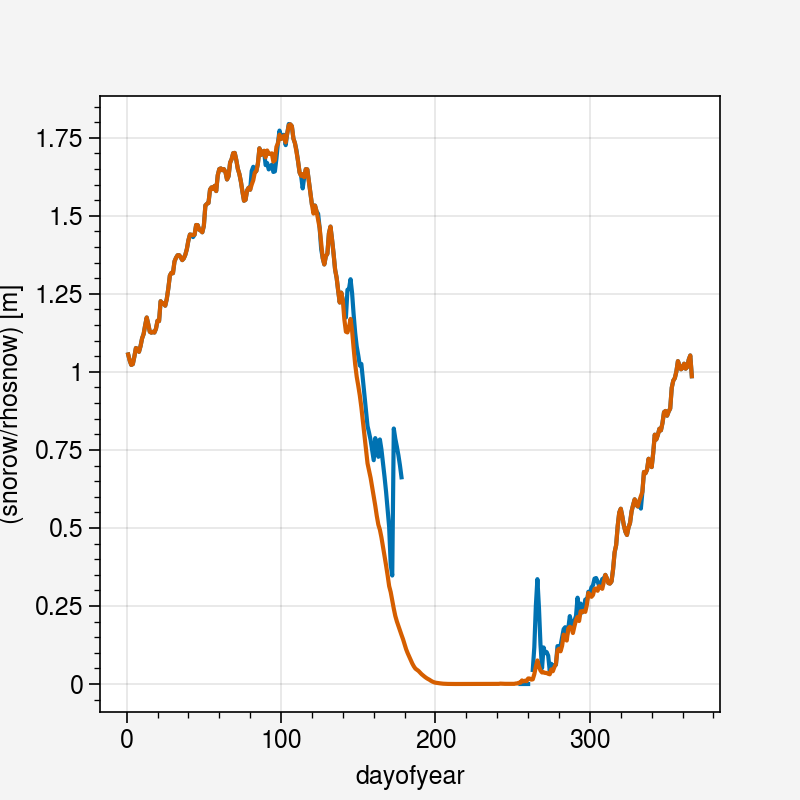

In [25]:
ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean().plot()
ds_d_SnowMIP_list[0][i].snd.sel(time=period).groupby('time.dayofyear').mean().plot()

In [26]:
SnowMIP_sites[5].name

'sod'

In [27]:
SnowMIP_sites[5].period_used

slice('2007-10-01', '2014-09-30', None)

In [28]:
i = 5
site = SnowMIP_sites[i]
period = site.period_used
ds_d_Obs_list[i].snd_auto.sel(time=period)

<xarray.DataArray 'snd_auto' (time: 2557)>
array([ 0.,  0.,  0., ..., nan, nan, nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2007-10-01 2007-10-02 ... 2014-09-30
Attributes:
    long_name:  snowdepth, automatic measurement
    units:      m

In [29]:
i = 5
mask_obs = ~ds_d_Obs_list[i].snd_auto.sel(time=period).isnull()
mask_obs

<xarray.DataArray 'snd_auto' (time: 2557)>
array([ True,  True,  True, ..., False, False, False])
Coordinates:
  * time     (time) datetime64[ns] 2007-10-01 2007-10-02 ... 2014-09-30

In [30]:
ds_d_SnowMIP_list[0][5]

<xarray.Dataset>
Dimensions:     (time: 2922, layer: 20)
Coordinates:
  * time        (time) datetime64[ns] 2007-01-01 2007-01-02 ... 2014-12-31
  * layer       (layer) float64 0.05 0.15 0.25 0.35 0.45 ... 8.9 18.9 41.4 58.9
Data variables: (12/54)
    longitude   float64 26.63
    latitude    float64 67.37
    actlyr      (time) float64 61.24 61.23 61.22 61.22 ... 61.24 61.23 61.24
    albs        (time) float64 0.8251 0.8109 0.8337 0.8287 ... 0.0 0.8044 0.0
    albsir      (time) float64 0.7123 0.6951 0.7228 0.7167 ... 0.0 0.6959 0.0
    albsn       (time) float64 0.8256 0.8175 0.8365 0.8318 ... 0.0 0.8291 0.0
    ...          ...
    tsn         (time) float64 -4.338 -5.738 -3.893 ... -0.04248 -0.6328
    tsnbot      (time) float64 -3.368 -4.692 -3.356 ... -0.03333 -0.493
    vegHeight   (time) float64 0.2261 0.2248 0.2234 ... 0.2335 0.2304 0.2273
    wsnw        (time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.1239 0.3153 0.1494 0.0
    wtd         (time) float64 9.999e+03 9.999e+03 ... 9.999e+03 9.999e+03
    zpond       (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    title:        CLASSIC output file
    timestamp:    20240826 1104
    Conventions:  COARDS
    node_offset:  1
    Comment:       run_DEF

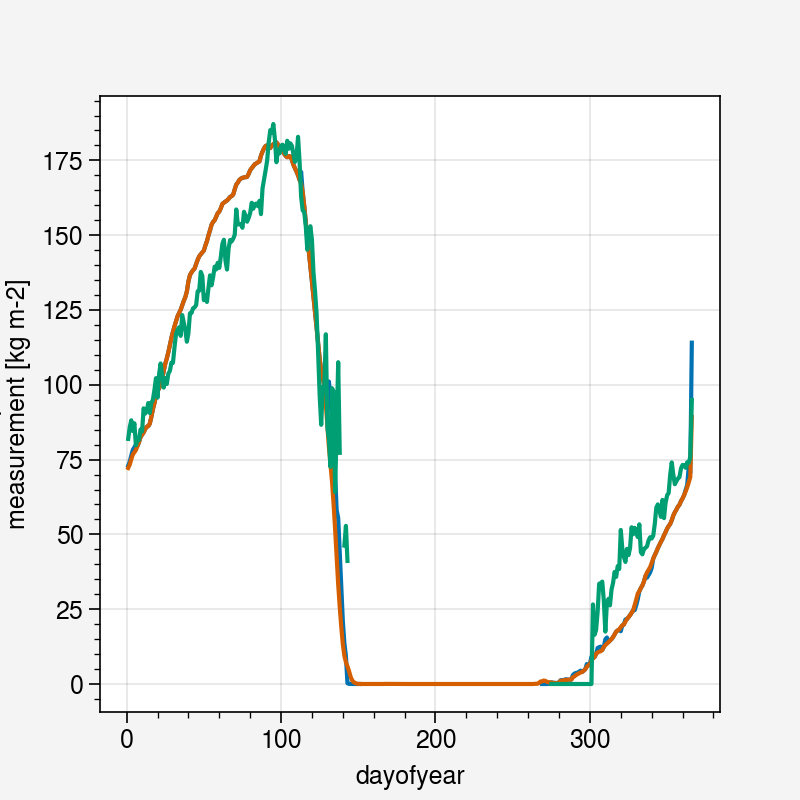

In [31]:
ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean().plot()
ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean().plot()
ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().plot()

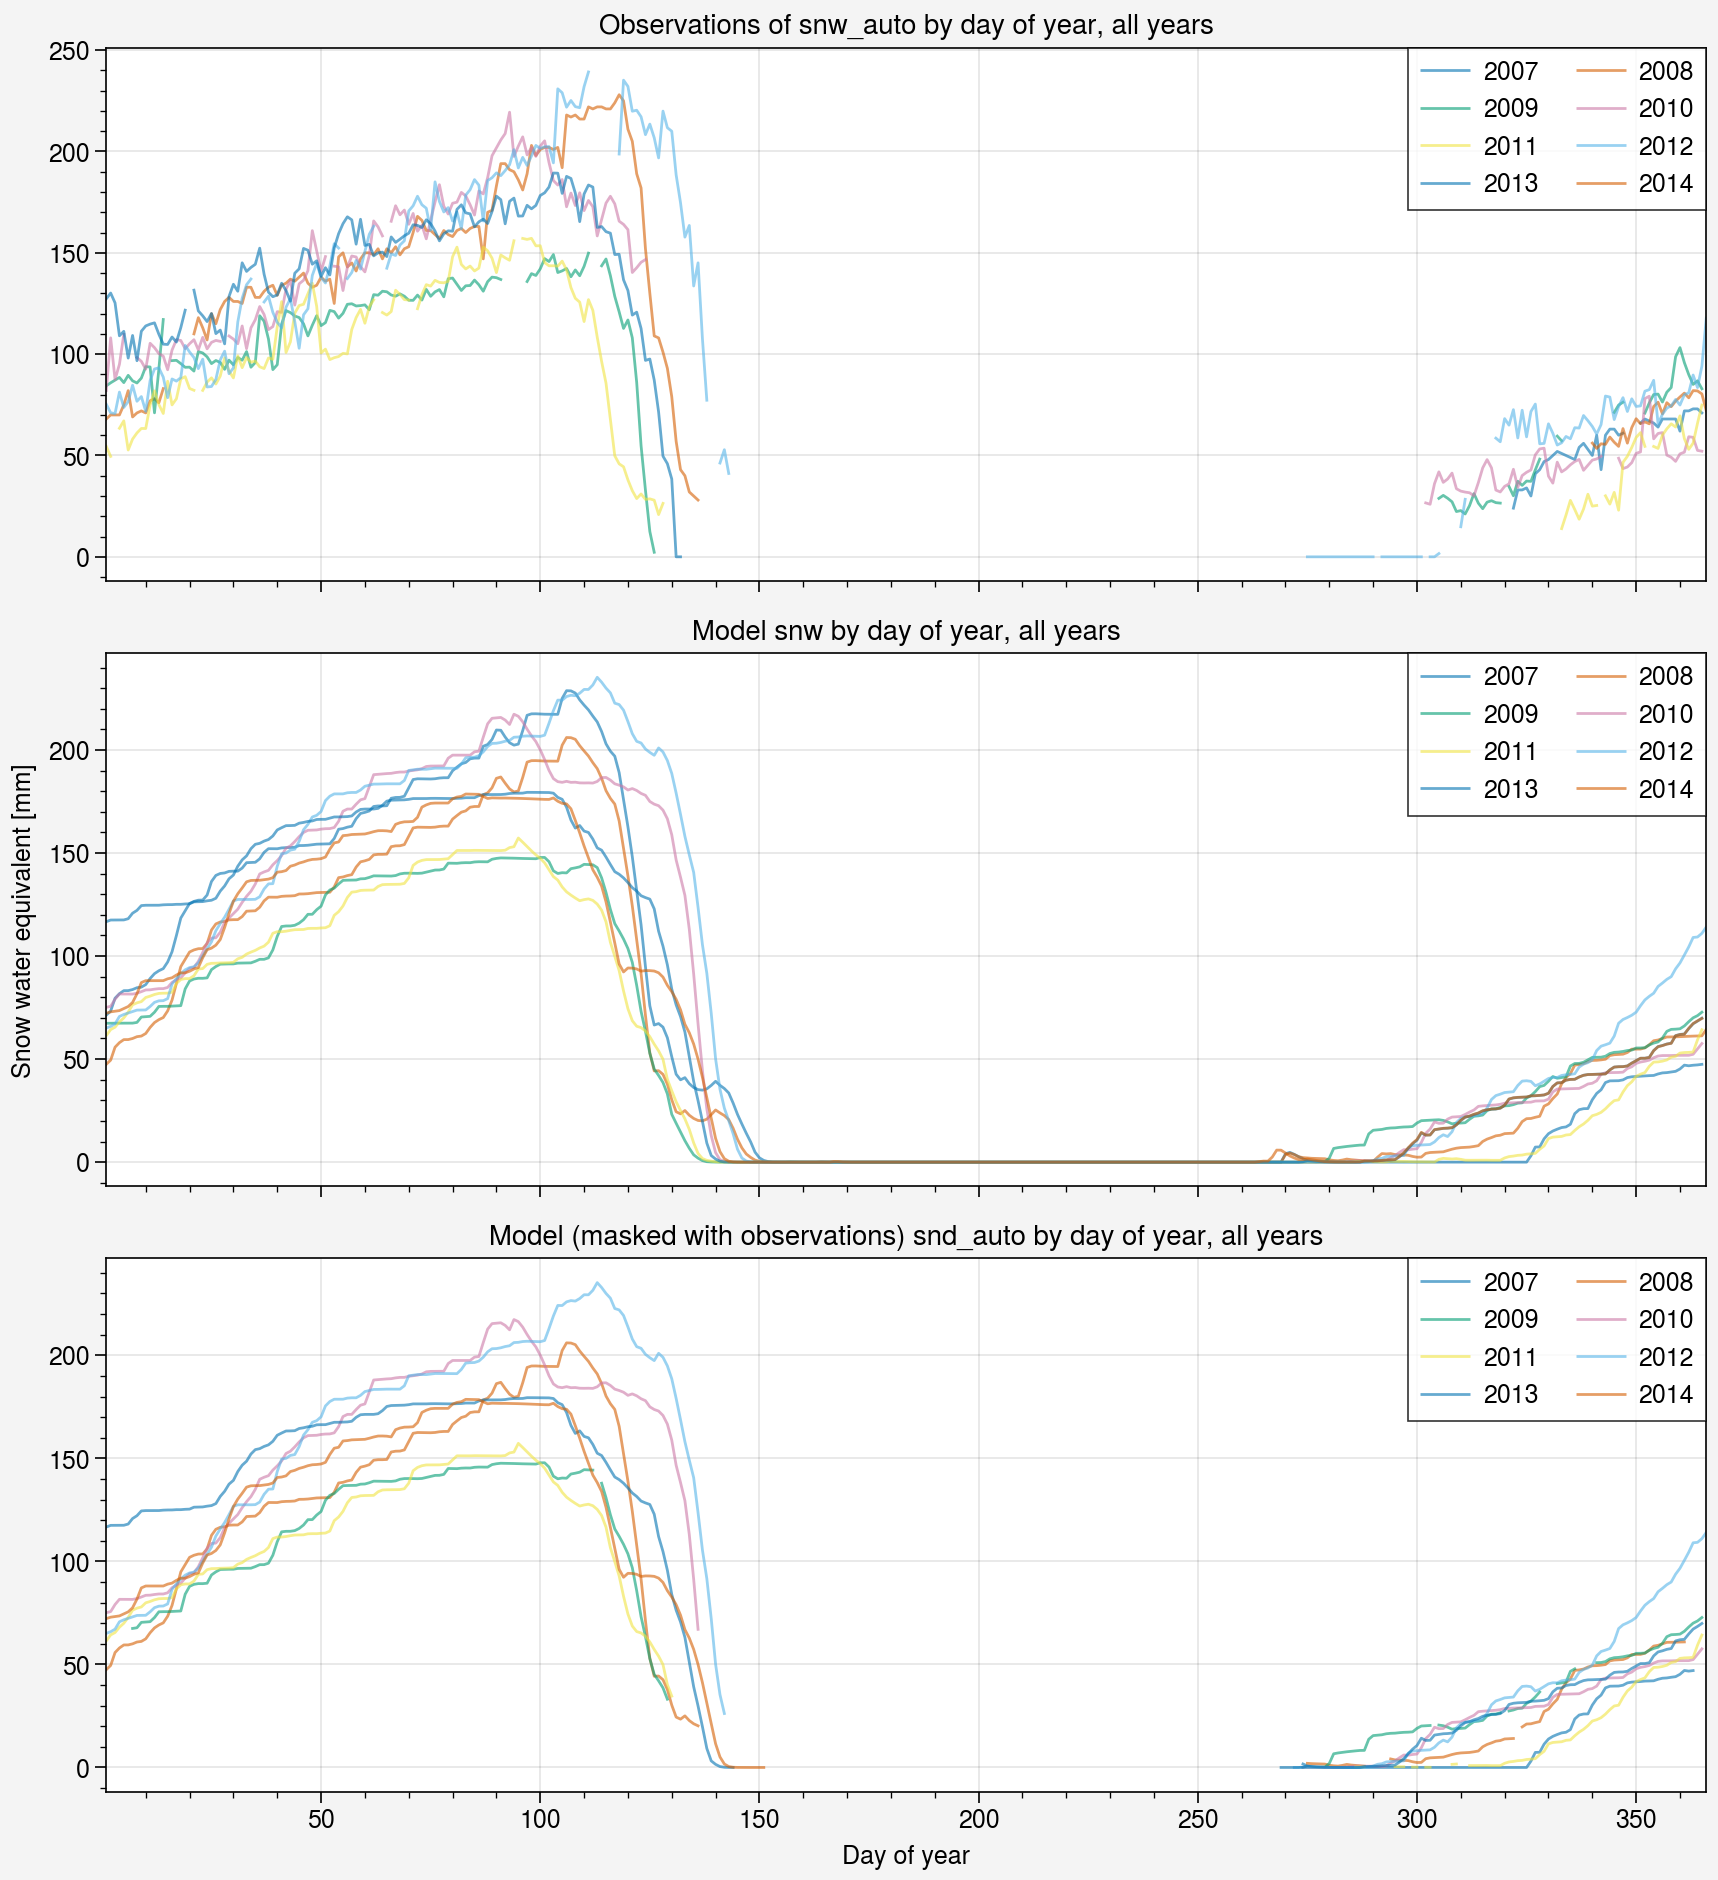

In [32]:
fig, axs = pplt.subplots(refwidth=8, refaspect=3, nrows=3)
i = 5 
ax = axs[0]
for year, da_y in ds_d_Obs_list[i].snw_auto.groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow water equivalent [mm]",
    title="Observations of snw_auto by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)

ax = axs[1]
for year, da_y in ds_d_SnowMIP_list[0][i].snw.groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow water equivalent [mm]",
    title="Model snw by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)

ax = axs[2]
for year, da_y in ds_d_SnowMIP_list[0][i].snw.where(mask_obs).groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow water equivalent [mm]",
    title="Model (masked with observations) snd_auto by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)

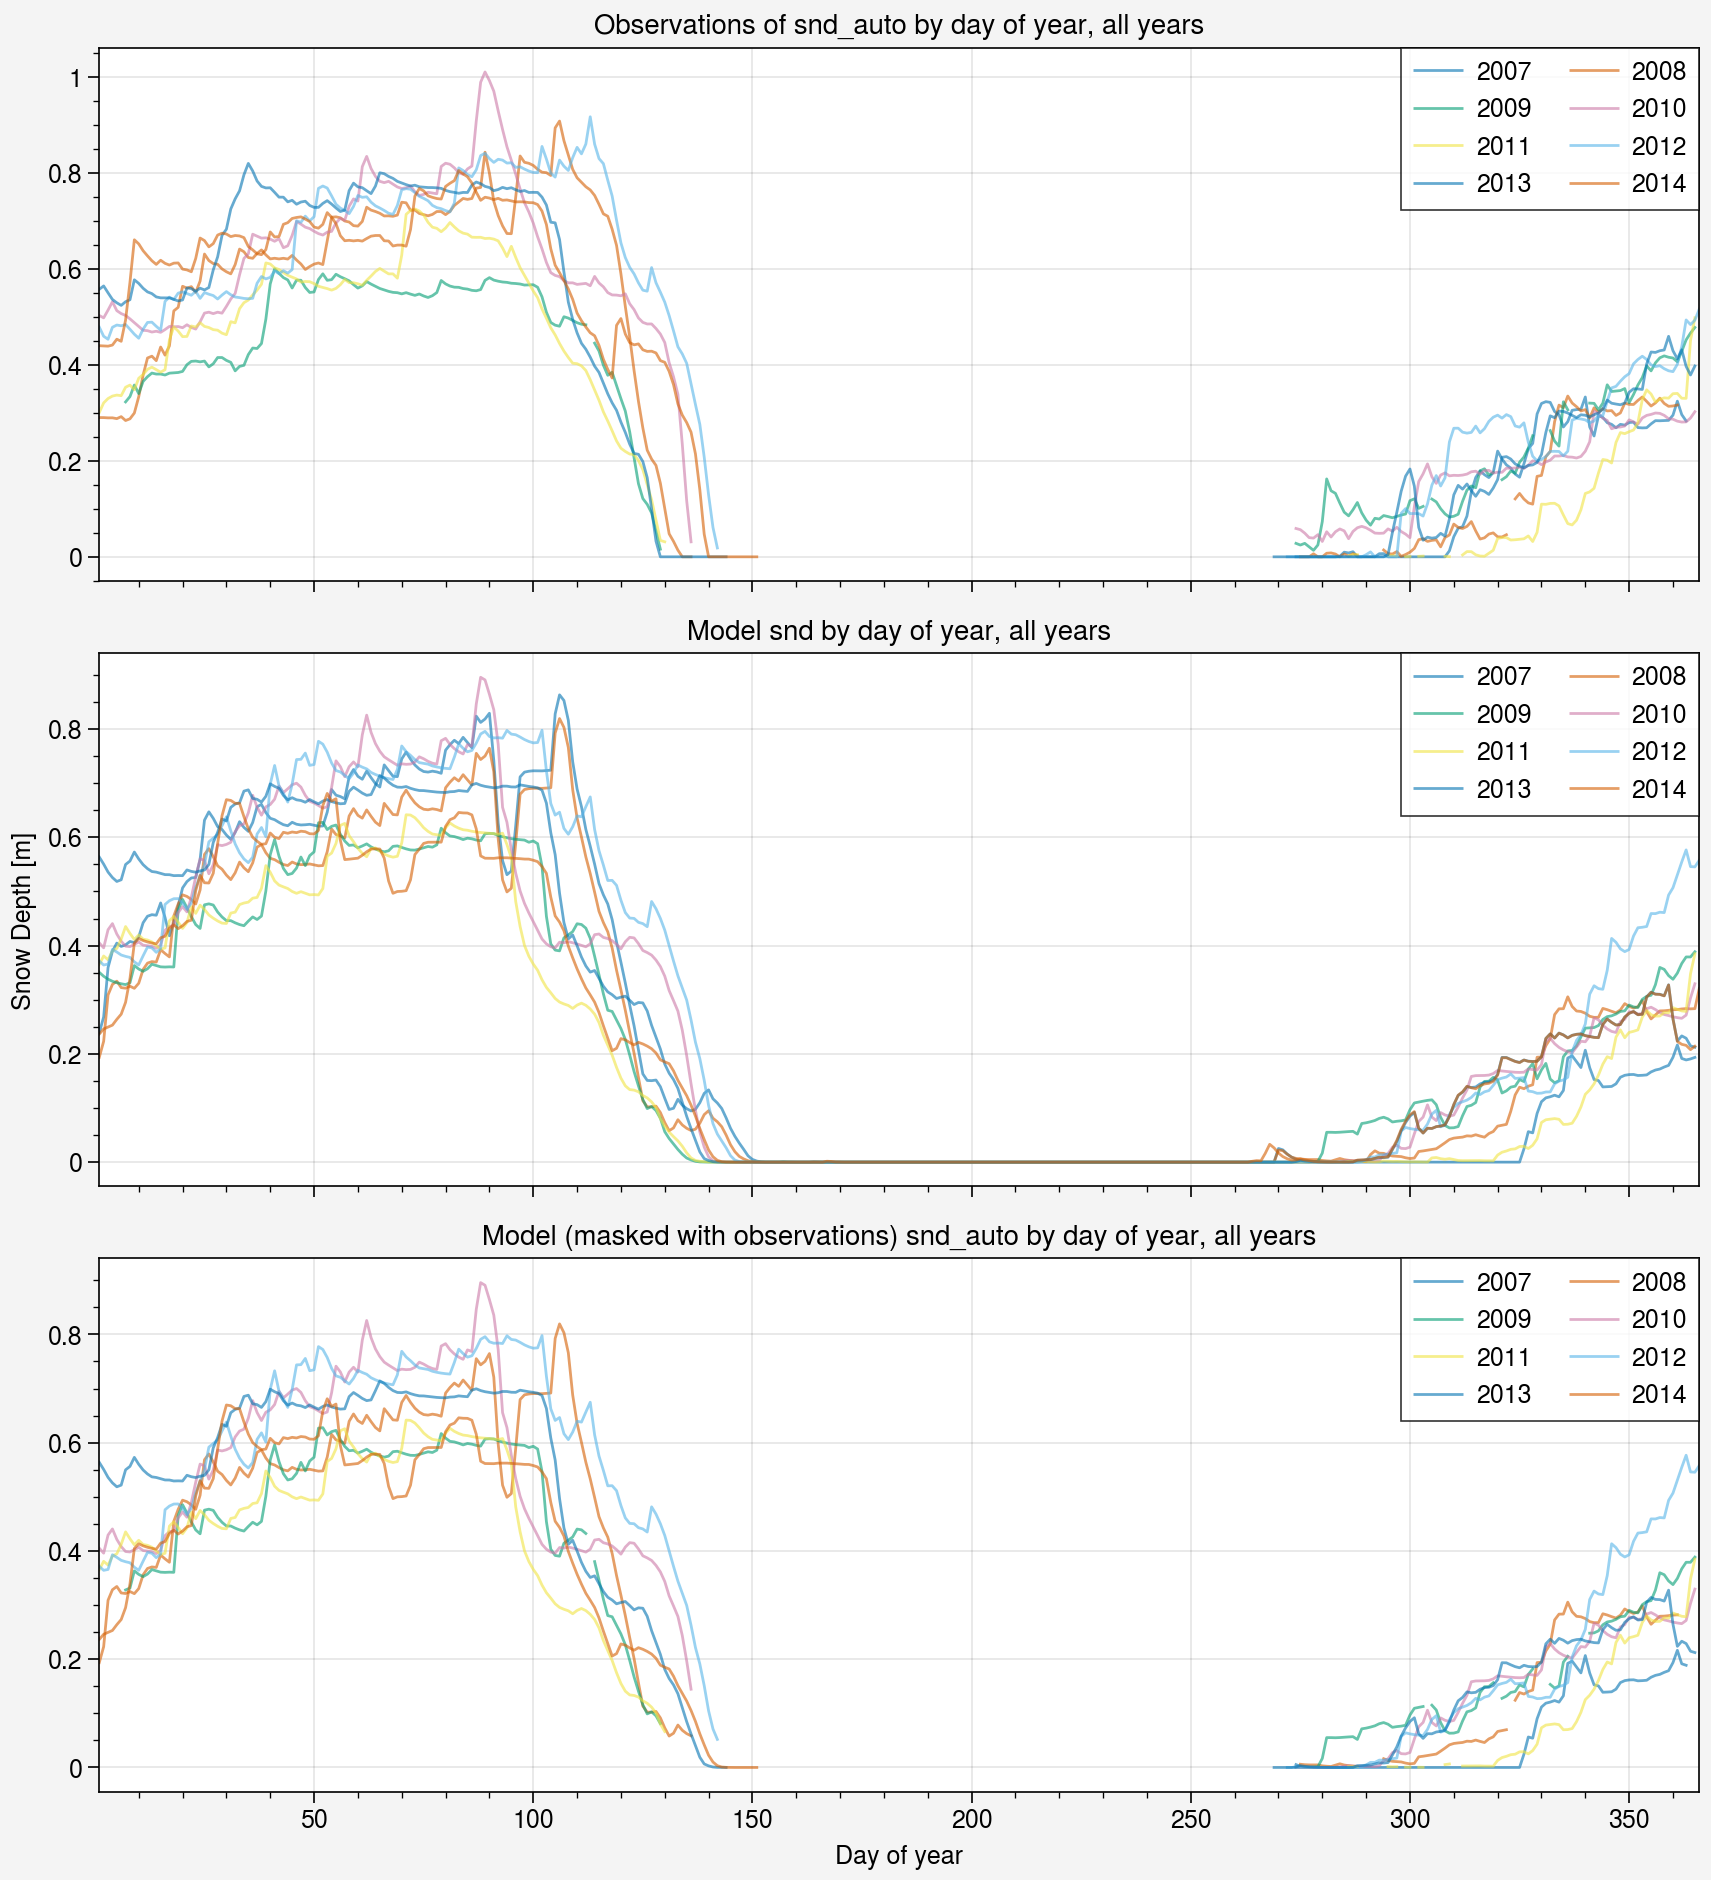

In [33]:
fig, axs = pplt.subplots(refwidth=8, refaspect=3, nrows=3)
i = 5 
ax = axs[0]
for year, da_y in ds_d_Obs_list[i].snd_auto.groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow Depth [m]",
    title="Observations of snd_auto by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)

ax = axs[1]
for year, da_y in ds_d_SnowMIP_list[0][i].snd.groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow Depth [m]",
    title="Model snd by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)

ax = axs[2]
for year, da_y in ds_d_SnowMIP_list[0][i].snd.where(mask_obs).groupby("time.year"):
    ax.plot(
        da_y.time.dt.dayofyear,
        da_y,
        label=str(year),
        alpha=0.6,
        lw=1
    )

ax.format(
    xlabel="Day of year",
    ylabel="Snow Depth [m]",
    title="Model (masked with observations) snd_auto by day of year, all years"
)
ax.legend(ncols=2, fontsize=8)